In [27]:
# Question 4

from scipy.integrate import solve_ivp,solve_bvp
import matplotlib.pyplot as plt
import numpy as np

T_0 = 100
h = 20
k = 14
L = 0.1
T_air = 20

def dydx(x, y):
    r = 0.02 - 0.1*x
    # y = [T, u]
    return [y[1]/r**2, ((2*h*r)/k)*(y[0]-T_air)]

def bcs(T0, TL):
    rL = 0.02 - 0.1*L
    # T0 = [T(0), u[0]]
    # TL = [T(L), u(L)]
    return [T0[0] - T_0, 
            ((k*(TL[1]/rL**2)) + h*(TL[0]-T_air))]

xvals=np.linspace(0, L, 100)
solve_bv = solve_bvp(dydx, bcs, xvals, np.zeros((2, xvals.size)))

In [28]:
solve_bv

       message: The algorithm converged to the desired accuracy.
       success: True
        status: 0
             x: [ 0.000e+00  1.010e-03 ...  9.899e-02  1.000e-01]
           sol: <scipy.interpolate._interpolate.PPoly object at 0x7f9b10a3e3b0>
             p: None
             y: [[ 1.000e+02  9.936e+01 ...  6.159e+01  6.153e+01]
                 [-2.562e-01 -2.516e-01 ... -7.138e-03 -5.932e-03]]
            yp: [[-6.405e+02 -6.354e+02 ... -6.996e+01 -5.932e+01]
                 [ 4.571e+00  4.512e+00 ...  1.200e+00  1.186e+00]]
 rms_residuals: [ 7.574e-08  1.911e-08 ...  1.091e-06  1.339e-06]
         niter: 1

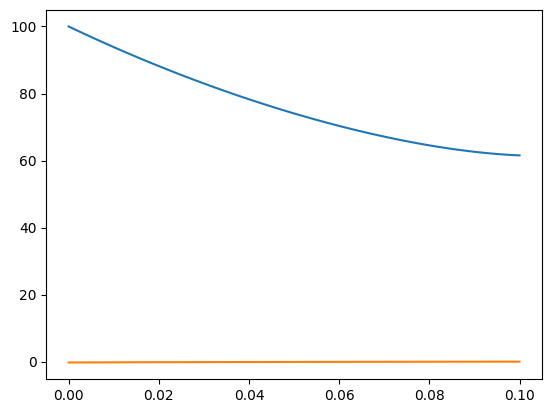

In [29]:
plt.plot(solve_bv.x, solve_bv.y[0])
plt.plot(solve_bv.x, solve_bv.y[1])

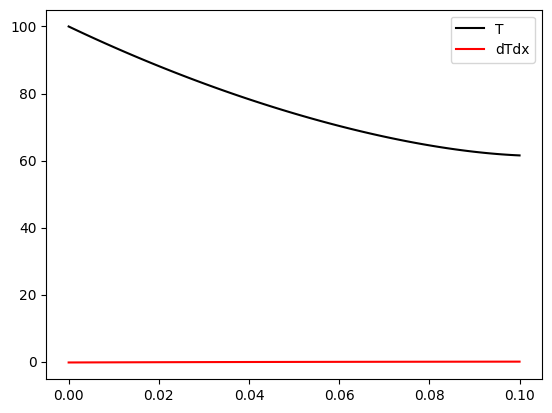

In [9]:
from scipy.integrate import solve_bvp
import matplotlib.pyplot as plt
import numpy as np

#parameters
h = 20   #W/m2/K
k = 14   #W/m/K
Tair = 20 
L = 0.1   #m

def dydx(x,y):
	 #y = [T u]
	 # where u = r^2 dT/dx
	 r = lambda x:0.02 - 0.1*x
	 rx=r(x)

	 dydx_arr = [y[1]/rx**2, 2*h/k*rx*(y[0]-Tair)]
	 return dydx_arr

def mybc(y0,yL):
	 # y0 = y(x = 0) = [T(0) u(0)]
	 # yL = y(x = L) = [T(L) u(L)]
	 r = lambda x:0.02 - 0.1*x
	 resid = [y0[0]-100,
              h*(yL[0]-Tair)+k*yL[1]/r(L)**2]
	 return resid    


# solve using solve_bvp  
x_vals=np.linspace(0,L,100)
sol=solve_bvp(dydx,mybc,x_vals,np.zeros((2,x_vals.size)))


#plot results

plt.figure()
plt.plot(sol.x,sol.y[0],'k-',label='T')
plt.plot(sol.x,sol.y[1],'r-',label='dTdx')
plt.legend()
plt.show()